<center>

<img src='https://micro.ce.sharif.edu/lib/tpl/writr/images/logo.svg' alt="SUT logo" width=500 height=300 align=center class="saturate" >


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
Machine Learning <br>
Course Project, Fall 2025 <br>
<font color=3C99D size=5>
EEG - Motor Imagery Classification <br>
<font color=3C99D size=6>
By: Mohammad Hossein Hosseinzadeh 403203557 , Farshad Vaziri 403206179
Group:  G45

<br>
<br>
<br>

</center>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import pi
import scipy.io as sio
from scipy.signal import butter, filtfilt
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, silhouette_samples, silhouette_score, confusion_matrix
)



np.random.seed(0)


## Section 1.1: Data Loading and Windowing

### Overview

In this section, we load the EEG data from the BCI Competition IV dataset and perform temporal windowing. The continuous EEG signal is segmented into fixed-length windows based on motor imagery cues. The windowing process creates a standard machine learning dataset format where each sample corresponds to one motor imagery trial.

**Key Steps:**
1. Load continuous EEG signal and extract metadata (sampling frequency, channel names, marker positions)
2. Perform temporal windowing: extract 4-second segments starting from each cue marker
3. Create dataset in standard ML format (features + labels)
4. Display dataset statistics and visualize sample channels

**Dataset Characteristics:**
- **File:** BCICIV_calib_ds1a.mat
- **Channels:** 59 EEG electrodes
- **Sampling Frequency:** 1000 Hz
- **Classes:** Left hand (-1) and Foot (1)
- **Window Duration:** 4 seconds = 4000 samples

In [5]:
def load_and_window_data(mat_file, scale_factor=0.1):
    """
        windows: [trials, time, channels]
        labels:  [trials]
        fs:      sampling rate
        chNames: channel names
    """
    data = sio.loadmat(mat_file, squeeze_me=True, struct_as_record=False)

    cnt = scale_factor * data['cnt'].astype(float)  # [time x channels]
    mrk = data['mrk']
    nfo = data['nfo']

    fs = float(nfo.fs)
    chNames = list(nfo.clab)

    win_duration = 4.0  # seconds
    win_samples = int(round(win_duration * fs))

    cue_pos = mrk.pos
    cue_labels = mrk.y
    num_cues = len(cue_pos)

    num_channels = cnt.shape[1]
    windows = np.zeros((num_cues, win_samples, num_channels))
    labels = np.zeros(num_cues, dtype=int)

    for i in range(num_cues):
        start_idx = int(cue_pos[i])
        end_idx = start_idx + win_samples

        if end_idx > cnt.shape[0]:
            segment = cnt[start_idx:, :]
            padded = np.zeros((win_samples, num_channels))
            padded[:segment.shape[0], :] = segment
            windows[i, :, :] = padded
        else:
            windows[i, :, :] = cnt[start_idx:end_idx, :]

        labels[i] = int(cue_labels[i])

    return windows, labels, fs, chNames


### 1.1.1: Load Data and Display Statistics

The following code loads the raw EEG data from the .mat file using the `load_and_window_data()` function we defined earlier. This function:
- Extracts the continuous signal (cnt) and scales it
- Reads marker positions and labels from the cue information
- Performs windowing with a 4-second duration
- Returns windowed data in shape [num_trials, num_samples, num_channels]

We then print comprehensive statistics about the loaded dataset including dimensions, class distribution, and sampling information.

In [6]:
# Load the data
windows, labels, fs, chNames = load_and_window_data("data/BCICIV_calib_ds1a.mat")

print(f"Total number of samples:        {windows.shape[0]}")
print(f"Window length (samples):        {windows.shape[1]}")
print(f"Window duration (seconds):      {windows.shape[1] / fs:.1f}")
print(f"Number of channels:             {windows.shape[2]}")
print(f"Sampling frequency (Hz):        {fs}")
print()
print(f"Unique classes:                 {np.unique(labels)}")
print(f"Class distribution:             {dict(zip(*np.unique(labels, return_counts=True)))}")



Total number of samples:        200
Window length (samples):        400
Window duration (seconds):      4.0
Number of channels:             59
Sampling frequency (Hz):        100.0

Unique classes:                 [-1  1]
Class distribution:             {np.int64(-1): np.int64(100), np.int64(1): np.int64(100)}


### 1.1.2: Visualize Sample Channels

Now we visualize one sample from the dataset to examine the raw EEG signals. We plot 5 specific channels (0, 15, 30, 45, 58) as time-series functions as required by the project specification. This visualization helps us understand the characteristics of the motor imagery signals before proceeding to preprocessing and feature extraction.

The plot shows:
- **X-axis:** Time in seconds (0 to 4 seconds)
- **Y-axis:** Signal amplitude in microvolts
- **5 Channels:** Distributed across the scalp (anterior, central, and posterior regions)
- **Signal Quality:** The raw EEG before any filtering

**Note on Train-Test Split:** Although we perform a 75/25 train-test split in the subsequent `run_pipeline()` function during classification (Section 2), we display statistics and visualizations on the full dataset here to understand its overall characteristics. The actual train-test split happens later when we process the filtered data and extract features for model training.

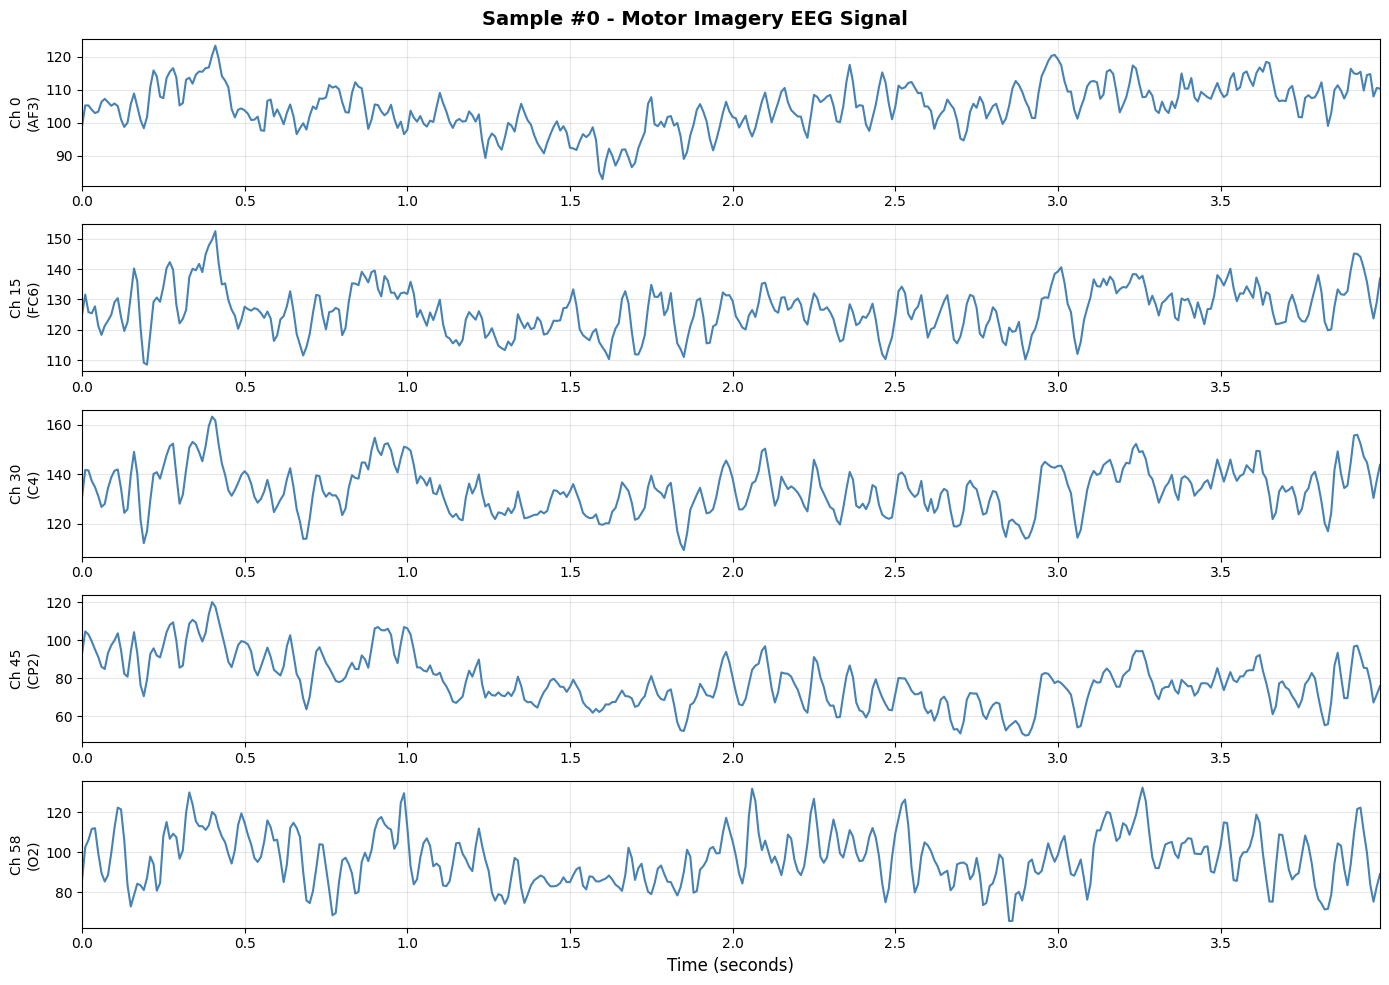

In [7]:
# Visualize one sample - channels 0, 15, 30, 45, 59
sample_idx = 0
channels_to_plot = [0, 15, 30, 45, 58]

time_axis = np.arange(windows.shape[1]) / fs

fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(14, 10))

for i, ch_idx in enumerate(channels_to_plot):
    axes[i].plot(time_axis, windows[sample_idx, :, ch_idx], linewidth=1.5, color='steelblue')
    axes[i].set_ylabel(f'Ch {ch_idx}\n({chNames[ch_idx]})', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, time_axis[-1]])

axes[-1].set_xlabel('Time (seconds)', fontsize=12)
fig.suptitle(f'Sample #{sample_idx} - Motor Imagery EEG Signal', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.1.3: Train-Test Split (75/25)

According to the project specification, after loading and windowing the data, we must split it into training (75%) and testing (25%) sets. This split is performed on the raw windowed data before any filtering or feature extraction. This ensures that the train and test sets represent independent data splits, which is essential for unbiased model evaluation.

In [8]:
#  Perform Train-Test Split (75/25) on raw windowed data
num_samples = windows.shape[0]
idx = np.random.permutation(num_samples)
train_count = int(round(0.75 * num_samples))
train_idx = idx[:train_count]
test_idx = idx[train_count:]

X_train_raw = windows[train_idx]
y_train = labels[train_idx]
X_test_raw = windows[test_idx]
y_test = labels[test_idx]


print(f"Total samples:                  {num_samples}")
print(f"Training samples (75%):         {len(X_train_raw)}")
print(f"Test samples (25%):             {len(X_test_raw)}")
print(f"Training set shape:             {X_train_raw.shape}")
print(f"Test set shape:                 {X_test_raw.shape}")
print(f"Training class distribution:    {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution:        {dict(zip(*np.unique(y_test, return_counts=True)))}")


Total samples:                  200
Training samples (75%):         150
Test samples (25%):             50
Training set shape:             (150, 400, 59)
Test set shape:                 (50, 400, 59)
Training class distribution:    {np.int64(-1): np.int64(73), np.int64(1): np.int64(77)}
Test class distribution:        {np.int64(-1): np.int64(27), np.int64(1): np.int64(23)}


# Section 1.2: Temporal Filtering - Bandpass Filter

## Overview

In this section, we apply a bandpass filter to the training and test data obtained from Section 1.1. Brain signals contain multiple frequency bands, but the Mu (8-13 Hz) and Beta (13-30 Hz) rhythms are most important for motor imagery classification. By filtering to 8-30 Hz, we remove noise, artifacts, and irrelevant frequency components while preserving the discriminative information.

**Filter Specifications:**
- **Type:** Butterworth filter
- **Configuration:** Bandpass (keeps frequencies between 8-30 Hz)
- **Order:** 4
- **Method:** Zero-phase filtering (filtfilt) to avoid phase distortion
- **Frequency Bands Preserved:**
  - **Mu rhythm:** 8-13 Hz (sensorimotor activity)
  - **Beta rhythm:** 13-30 Hz (motor preparation and execution)


In [9]:
def bandpass_filter_eeg(windows, fs, low_cut, high_cut, order=4):
    """
    معادل MATLAB: bandpass_filter_eeg.m
    windows: [trials, time, channels]
    """
    num_trials, num_samples, num_channels = windows.shape
    b, a = butter(order, [low_cut, high_cut], btype='bandpass', fs=fs)

    windows_filt = np.zeros_like(windows)
    for tr in range(num_trials):
        for ch in range(num_channels):
            sig = windows[tr, :, ch]
            sig_filt = filtfilt(b, a, sig)
            windows_filt[tr, :, ch] = sig_filt
    return windows_filt


## 1.2.1: Apply Bandpass Filter to Training and Test Data

Apply the 8-30 Hz bandpass filter to both training and test sets independently. This preserves the Mu and Beta frequency bands while removing high-frequency noise and low-frequency drift.


In [10]:
# Apply bandpass filter to training and test data independently
X_train_filt = bandpass_filter_eeg(X_train_raw, fs, low_cut=8, high_cut=30, order=4)
X_test_filt = bandpass_filter_eeg(X_test_raw, fs, low_cut=8, high_cut=30, order=4)

print(f"Filter type:                    Butterworth Bandpass")
print(f"Filter order:                   4")
print(f"Frequency range:                8-30 Hz (Mu + Beta bands)")
print(f"\nTraining set:")
print(f"  - Before filtering:           {X_train_raw.shape}")
print(f"  - After filtering:            {X_train_filt.shape}")
print(f"\nTest set:")
print(f"  - Before filtering:           {X_test_raw.shape}")
print(f"  - After filtering:            {X_test_filt.shape}")



Filter type:                    Butterworth Bandpass
Filter order:                   4
Frequency range:                8-30 Hz (Mu + Beta bands)

Training set:
  - Before filtering:           (150, 400, 59)
  - After filtering:            (150, 400, 59)

Test set:
  - Before filtering:           (50, 400, 59)
  - After filtering:            (50, 400, 59)


## 1.2.2: Visualize Filtering Results - Before and After

Compare the raw (unfiltered) signal with the bandpass filtered signal for one sample across the 5 specific channels (0, 15, 30, 45, 59). This side-by-side visualization demonstrates the effectiveness of the bandpass filter in removing noise and artifacts.

**Observations:**
- **Left panels (Raw):** Original signal with high-frequency noise and low-frequency drift
- **Right panels (Filtered):** Cleaned signal with noise removed, highlighting the underlying motor imagery rhythms
- **Amplitude reduction:** The filtered signal typically has smaller amplitude, indicating successful removal of noise components
- **Signal quality:** The filtered signal shows smoother, more regular oscillations characteristic of motor imagery activity

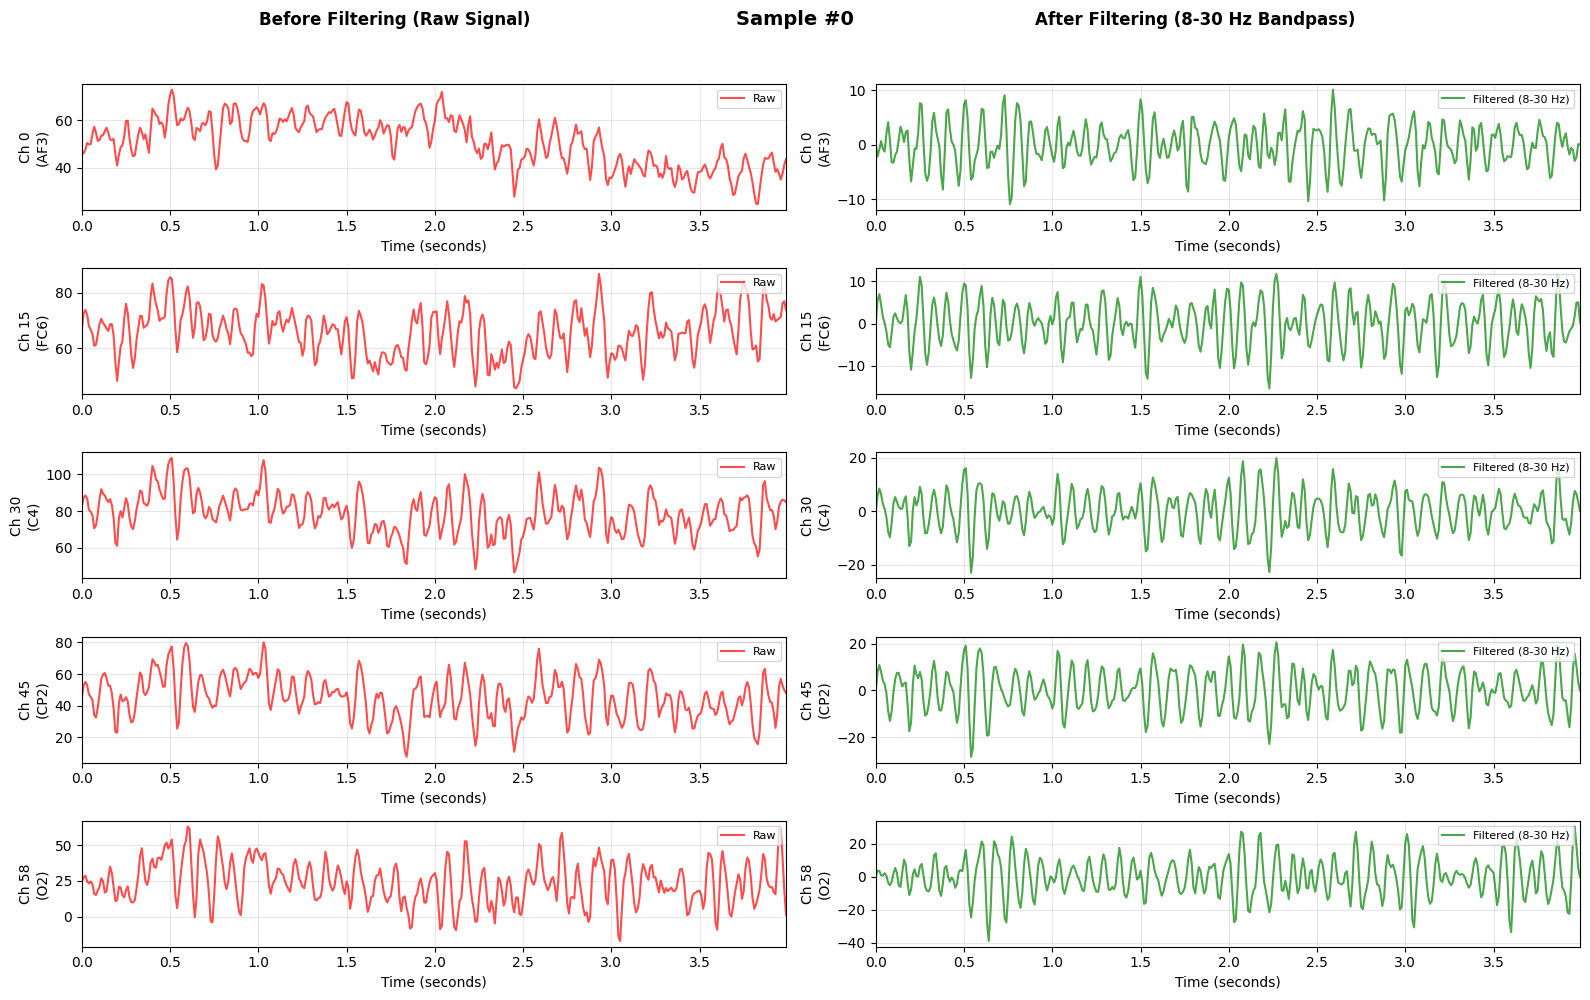

In [11]:
# Compare raw signal vs filtered signal for visualization
sample_idx = 0
channels_to_plot = [0, 15, 30, 45, 58]

time_axis = np.arange(X_train_raw.shape[1]) / fs

fig, axes = plt.subplots(len(channels_to_plot), 2, figsize=(16, 10))

for i, ch_idx in enumerate(channels_to_plot):
    # Raw signal (before filtering)
    axes[i, 0].plot(time_axis, X_train_raw[sample_idx, :, ch_idx],
                    linewidth=1.5, color='red', alpha=0.7, label='Raw')
    axes[i, 0].set_ylabel(f'Ch {ch_idx}\n({chNames[ch_idx]})', fontsize=10)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].set_xlim([0, time_axis[-1]])
    axes[i, 0].legend(loc='upper right', fontsize=8)

    # Filtered signal (after bandpass filter)
    axes[i, 1].plot(time_axis, X_train_filt[sample_idx, :, ch_idx],
                    linewidth=1.5, color='green', alpha=0.7, label='Filtered (8-30 Hz)')
    axes[i, 1].set_ylabel(f'Ch {ch_idx}\n({chNames[ch_idx]})', fontsize=10)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].set_xlim([0, time_axis[-1]])
    axes[i, 1].legend(loc='upper right', fontsize=8)

# Set x-axis labels
for i in range(len(channels_to_plot)):
    axes[i, 0].set_xlabel('Time (seconds)', fontsize=10)
    axes[i, 1].set_xlabel('Time (seconds)', fontsize=10)

# Overall titles
fig.text(0.25, 0.98, 'Before Filtering (Raw Signal)',
         ha='center', fontsize=12, fontweight='bold')
fig.text(0.75, 0.98, 'After Filtering (8-30 Hz Bandpass)',
         ha='center', fontsize=12, fontweight='bold')

fig.suptitle(f'Sample #{sample_idx}',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Section 1.3: Feature Extraction - Common Spatial Patterns

## Overview

In this section, we extract discriminative features from the filtered EEG signals using the Common Spatial Patterns (CSP) algorithm. Due to the proximity of electrodes on the scalp, signals from different channels mix together spatially. CSP finds spatial filters that maximize the variance difference between motor imagery classes, thereby enhancing class separability in the feature space.

**Key Concepts:**
- **Spatial Filtering:** Combines signals from multiple channels to create new virtual channels
- **Discriminative Features:** CSP extracts features most informative for class discrimination
- **Dimensionality Reduction:** Reduces from [samples, time, 59 channels] to [samples, num_components]
- **Log-Variance Features:** Uses logarithm of variance as the final feature representation

**CSP Algorithm Characteristics:**
- Works with two-class problems
- Finds patterns that maximize variance ratio between classes
- Returns both class-1 dominant and class-2 dominant patterns
- Highly effective for motor imagery EEG classification

---

## 1.3.1: Understanding Common Spatial Patterns (CSP) Algorithm

**How CSP Works:**

Common Spatial Patterns is a spatial filter learning algorithm that finds the best linear combinations of EEG channels to maximize the variance difference between two motor imagery classes. Here's the mathematical process:

**Step 1: Compute Normalized Covariance Matrices**
- For each trial, compute the covariance matrix: C = X^T × X (where X is [time × channels])
- Normalize by trace: C_norm = C / trace(C)
- Average covariance across all trials of each class: R₁ (class 1) and R₂ (class 2)

**Step 2: Composite Covariance Matrix**
- R = R₁ + R₂ (sum of both class covariances)

**Step 3: Solve Generalized Eigenvalue Problem**
- Find eigenvectors W that solve: R₁ w = λ R w
- This maximizes the ratio of variances between classes
- Eigenvectors are sorted by eigenvalues in descending order

**Step 4: Select CSP Patterns**
- Select first m eigenvectors (maximizing class 1 variance)
- Select last m eigenvectors (minimizing class 1 variance = maximizing class 2 variance)
- With m = 3 components per class → total 6 CSP components

**Step 5: Extract Log-Variance Features**
- For each sample: project into CSP space → Z = X @ W (where Z is [time × num_components])
- Compute variance along each pattern: var_i = var(Z_i, axis=0)
- Normalize and take logarithm: f_i = log(var_i / sum(var))
- This creates the final feature vector [6-dimensional for 6 components]

**Why Log-Variance?**
- Makes the distribution more Gaussian
- Provides scale invariance
- Improves classifier performance
- Natural representation for power-based features

**Advantages for Motor Imagery:**
- CSP automatically finds spatial filters specific to motor imagery classes
- Emphasizes differences in Mu and Beta rhythms between different movements
- Reduces noise and artifacts through spatial filtering
- Significantly improves classification accuracy (often 5-10% improvement)
- Reduces feature dimension from [time × 59 channels] to [6 features]

---

In [12]:
def compute_class_covariance(Xc):
    """
    Xc: [trials, time, channels]
    خروجی: R [channels x channels]
    """
    num_trials, _, num_channels = Xc.shape
    R = np.zeros((num_channels, num_channels))
    for i in range(num_trials):
        Xi = Xc[i, :, :]  # [time x channels]
        Ci = Xi.T @ Xi
        Ci = Ci / np.trace(Ci)
        R += Ci
    R /= num_trials
    return R


def compute_csp(X, y, num_components):
    """
    معادل MATLAB: compute_csp.m
    X: [trials, time, channels]
    y: [trials] با دو کلاس (مثلاً -1 و 1)
    """
    if num_components % 2 != 0:
        raise ValueError("numComponents must be even.")
    
    classes = np.unique(y)
    if len(classes) != 2:
        raise ValueError("CSP is defined for two classes only.")
    
    class1, class2 = classes[0], classes[1]
    
    R1 = compute_class_covariance(X[y == class1])
    R2 = compute_class_covariance(X[y == class2])
    R = R1 + R2
    
    # generalized eigenvalue problem: R1 w = λ R w
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(R) @ R1)
    idx = np.argsort(eigvals)[::-1]
    E = eigvecs[:, idx]
    
    m = num_components // 2
    W = np.concatenate([E[:, :m], E[:, -m:]], axis=1)
    return W


def extract_csp_features(X, W):
    """
    معادل MATLAB: extract_csp_features.m
    X: [trials, time, channels]
    W: [channels, num_components]
    خروجی: [trials, num_components]
    """
    num_trials = X.shape[0]
    num_components = W.shape[1]
    features = np.zeros((num_trials, num_components))
    
    for i in range(num_trials):
        Xi = X[i, :, :]  # [time x channels]
        Z = Xi @ W       # [time x num_components]
        varZ = np.var(Z, axis=0, ddof=1)
        features[i, :] = np.log(varZ / np.sum(varZ))
    return features


## 1.3.2: Apply CSP and Extract Features

Now we apply the CSP algorithm to the filtered training data to learn the spatial patterns, then use these patterns to extract features from both training and test data.


In [13]:
# CSP parameters
num_csp_components = 6  # 3 components per class

# Train CSP on filtered training data
W_csp = compute_csp(X_train_filt, y_train, num_csp_components)

# Extract CSP features from filtered data
feat_train_csp = extract_csp_features(X_train_filt, W_csp)
feat_test_csp = extract_csp_features(X_test_filt, W_csp)

print(f"CSP Components:                 {num_csp_components}")
print(f"CSP Weights shape:              {W_csp.shape}")
print(f"Training features shape:        {feat_train_csp.shape}")
print(f"Test features shape:            {feat_test_csp.shape}")
print(f"Feature vector per sample:      {num_csp_components} values")
print(f"Feature range (training):       [min={feat_train_csp.min():.3f}, max={feat_train_csp.max():.3f}]")
print(f"Dimensionality reduction:       59 channels → {num_csp_components} features")

CSP Components:                 6
CSP Weights shape:              (59, 6)
Training features shape:        (150, 6)
Test features shape:            (50, 6)
Feature vector per sample:      6 values
Feature range (training):       [min=-3.869, max=-0.504]
Dimensionality reduction:       59 channels → 6 features
